In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import add_remaining_useful_life, add_rolling_features
from train_lstm import prepare_sequences, create_lstm_model
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

print("✓ All modules loaded!")

I0000 00:00:1777295071.781051    8252 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777295071.872042    8252 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777295074.591443    8252 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✓ All modules loaded!


In [2]:
# Load and prepare data
columns = ['unit', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

train_raw = pd.read_csv('../data/train_FD001.txt', sep=' ', header=None)
train_raw.drop(train_raw.columns[[26, 27]], axis=1, inplace=True)
train_raw.columns = columns

# Add RUL
train_data = add_remaining_useful_life(train_raw)

# Add rolling features
important_sensors = ['sensor2', 'sensor3', 'sensor4', 'sensor7', 
                     'sensor11', 'sensor12', 'sensor15', 'sensor20']
train_data = add_rolling_features(train_data, important_sensors, window=5)

print(f"✓ Data prepared: {train_data.shape}")
print(f"✓ Features: {len([col for col in train_data.columns if 'sensor' in col or 'rolling' in col])}")

# Select feature columns
feature_cols = [col for col in train_data.columns 
                if col.startswith('sensor') or 'rolling' in col]

print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols[:10], '...')

✓ Data prepared: (20631, 43)
✓ Features: 37

Feature columns (37):
['sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10'] ...


In [3]:
# Normalize features (important for neural networks)
scaler = MinMaxScaler()
train_data[feature_cols] = scaler.fit_transform(train_data[feature_cols])

print("✓ Features normalized (0-1 range)")

# Prepare sequences for LSTM
sequence_length = 30  # Use last 30 cycles to predict RUL

print(f"\nPreparing sequences (length={sequence_length})...")
X_train, y_train = prepare_sequences(train_data, sequence_length)

print(f"✓ Sequences created!")
print(f"X_train shape: {X_train.shape} (samples, sequence_length, features)")
print(f"y_train shape: {y_train.shape} (samples,)")
print(f"\nExample:")
print(f"- Input: Last {sequence_length} cycles with {X_train.shape[2]} features each")
print(f"- Output: RUL = {y_train[0]:.1f} cycles")

✓ Features normalized (0-1 range)

Preparing sequences (length=30)...
✓ Sequences created!
X_train shape: (17631, 30, 37) (samples, sequence_length, features)
y_train shape: (17631,) (samples,)

Example:
- Input: Last 30 cycles with 37 features each
- Output: RUL = 161.0 cycles


In [4]:
from sklearn.model_selection import train_test_split

# Split train/validation (80/20)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_split.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# Create LSTM model
model = create_lstm_model(
    sequence_length=sequence_length,
    n_features=X_train.shape[2]
)

print("\n" + "="*50)
print("LSTM MODEL ARCHITECTURE")
print("="*50)
model.summary()

Training set: 14104 samples
Validation set: 3527 samples

LSTM MODEL ARCHITECTURE


E0000 00:00:1777295267.981071    8252 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        26,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,073 (152.63 KB)

 Trainable params: 39,073 (152.63 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
import time

print("Starting training...")
print("This will take 2-3 minutes on CPU...\n")

start_time = time.time()

# Train model
history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    verbose=1
)

training_time = time.time() - start_time

print(f"\n✓ Training completed in {training_time:.1f} seconds!")
print(f"Final training loss: {history.history['loss'][-1]:.2f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.2f}")

Starting training...
This will take 2-3 minutes on CPU...

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 9863.5908 - mae: 79.3856 - val_loss: 6947.9531 - val_mae: 64.5713
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 5005.4702 - mae: 55.0744 - val_loss: 3787.6475 - val_mae: 49.7907
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 3890.8203 - mae: 50.6273 - val_loss: 3733.9124 - val_mae: 49.8961
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 3890.1348 - mae: 50.7509 - val_loss: 3733.7441 - val_mae: 49.9274
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 3892.9260 - mae: 50.7990 - val_loss: 3735.8994 - val_mae: 49.8512
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 3876.3652 - mae: 50.5962 - val_loss: 3733.7344 - val_mae: 49.9141
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 3885.5334 - mae: 50.6879 - val_loss: 3733.9185 - val_mae: 49.8956
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/ste

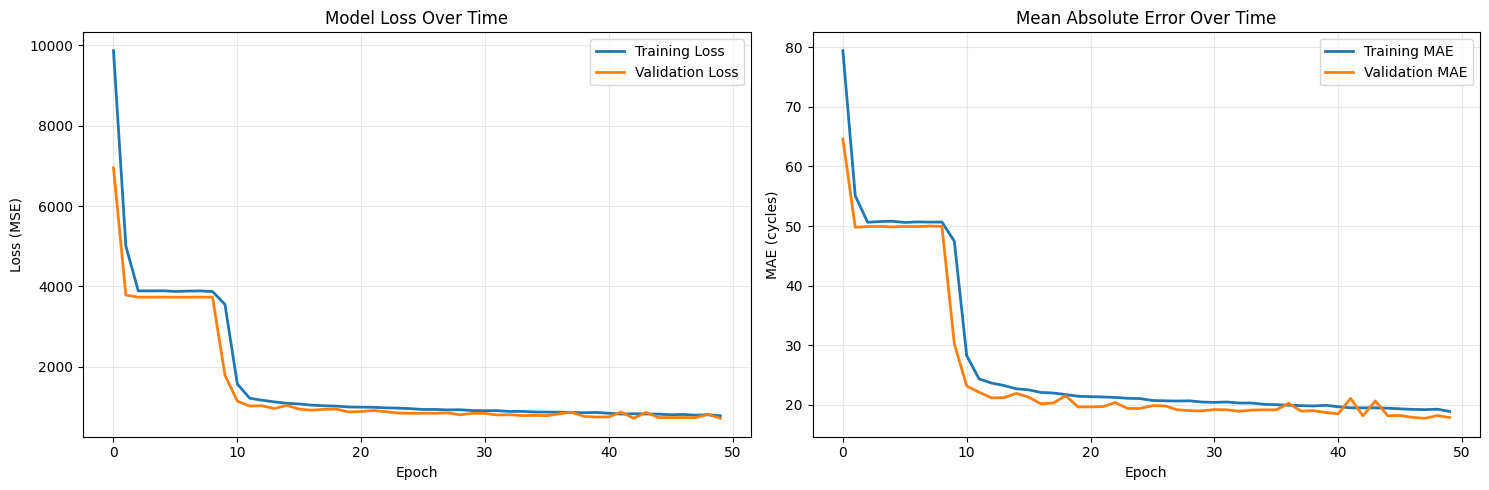

Best validation MAE: 17.76 cycles (Epoch 48)


In [6]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Model Loss Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (cycles)')
axes[1].set_title('Mean Absolute Error Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best validation MAE: {min(history.history['val_mae']):.2f} cycles (Epoch {history.history['val_mae'].index(min(history.history['val_mae']))+1})")